In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from pathlib import Path
from itertools import combinations
from collections import defaultdict, Counter
import networkx as nx
from scipy.stats import wilcoxon, mannwhitneyu
from statsmodels.stats.multitest import multipletests


In [27]:
target_long_df = pd.read_parquet(
    "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/new_parquets/rank1_target_contacts_long_5A.parquet"
)

In [29]:
rmsd_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/rmsd_data/new_parquets/5Å/pairwise_method_comparisons_rank1_with_binder_aligned_rmsd_5Å.parquet")
rmsd_df.columns.to_list()

['binder_sequence',
 'method_1',
 'method_2',
 'structure_path_1',
 'structure_path_2',
 'file_type_1',
 'file_type_2',
 'binder_chain_1',
 'binder_chain_2',
 'target_chain_1',
 'target_chain_2',
 'score_1',
 'score_2',
 'score_name_1',
 'score_name_2',
 'binder_ca_rmsd_align_binder',
 'n_ca_aligned',
 'binder_len_1',
 'binder_len_2',
 'status',
 'error']

In [30]:
pocket_aligned_rmsd_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/rmsd_data/new_parquets/directed_method_comparisons_rank1_with_overlap_target_pocket_rmsd.parquet")
pocket_aligned_rmsd_df.columns.to_list()


['binder_sequence',
 'reference_method',
 'query_method',
 'structure_path_1',
 'structure_path_2',
 'file_type_1',
 'file_type_2',
 'binder_chain_1',
 'binder_chain_2',
 'target_chain_1',
 'target_chain_2',
 'score_1',
 'score_2',
 'score_name_1',
 'score_name_2',
 'binder_ca_rmsd_pocket_align',
 'n_shell_residues_ref',
 'n_shell_ca_aligned',
 'n_binder_ca_compared',
 'target_shell_cutoff',
 'status_target_shell',
 'error_target_shell',
 'n_interface_residues_1',
 'n_interface_residues_2',
 'n_shared_interface_residues',
 'interface_overlap_method_1',
 'interface_overlap_method_2',
 'interface_overlap_max',
 'interface_overlap_threshold',
 'alignment_mode',
 'n_alignment_residues_selected',
 'n_alignment_ca_aligned',
 'residue_match_mode']

In [31]:
seq = "MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFKEIAKKDKEVAIEAFKVMAEYYDYNKGIEVALNK"
rmsd_col = "binder_ca_rmsd_pocket_align"

af3_seq_df = pocket_aligned_rmsd_df[
    (pocket_aligned_rmsd_df["binder_sequence"] == seq) &
    ((pocket_aligned_rmsd_df["reference_method"] == "AF3"))
].copy()


result = af3_seq_df[[
    "binder_sequence",
    "reference_method",
    "query_method",
    "alignment_mode",
    rmsd_col
]]

print(result)

                                         binder_sequence reference_method  \
11024  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...              AF3   
11025  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...              AF3   
11026  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...              AF3   
11027  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...              AF3   
11028  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...              AF3   
11029  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...              AF3   
11030  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...              AF3   
11031  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...              AF3   

      query_method       alignment_mode  binder_ca_rmsd_pocket_align  
11024          AF2  reference_interface                    52.338511  
11025      Boltz-2  reference_interface                    51.542284  
11026       Chai-1  reference_interface                    52.596750  
11027   HelixFold3  re

In [32]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results_old/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [33]:
rmsd_merged = rmsd_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
rmsd_merged = rmsd_merged.drop(columns=["sequence"])

In [34]:
pocket_merged = pocket_aligned_rmsd_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
pocket_merged = pocket_merged.drop(columns=["sequence"])

In [35]:
target_merged = target_long_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
target_merged = target_merged.drop(columns=["sequence"])

In [36]:
plot_rmsd = rmsd_merged[rmsd_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [37]:
plot_pocket = pocket_merged[pocket_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [38]:
plot_pocket.loc[plot_pocket["binder_ca_rmsd_pocket_align"].idxmax()]

binder_sequence                  MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFK...
reference_method                                                               AF3
query_method                                                            HelixFold3
structure_path_1                 /home/postyr/Assessing-AI-Scoring-Accuracy-for...
structure_path_2                 /home/postyr/Assessing-AI-Scoring-Accuracy-for...
file_type_1                                                                   .cif
file_type_2                                                                   .cif
binder_chain_1                                                                   A
binder_chain_2                                                                 A-1
target_chain_1                                                                   B
target_chain_2                                                                 B-1
score_1                                                                        0.3
scor

In [39]:
row = plot_pocket.loc[plot_pocket["binder_ca_rmsd_pocket_align"].idxmax()]

print("binder_sequence:")
print(row["binder_sequence"])

print("\nstructure_path_1")
print(row["structure_path_1"])


binder_sequence:
MSEEDLKEAVEKTLKSEDYVYVTWSGGNTDKIPFEKFGKEKAEKFKEIAKKDKEVAIEAFKVMAEYYDYNKGIEVALNK

structure_path_1
/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Predictions/AF3/minji.lee.386/seed-0_sample-1/minji.lee.386_seed-0_sample-1_model.cif


In [40]:
plot_target = target_merged[target_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [41]:
# Create contact sets: (binder, method) → set of residues
contact_sets = (
    plot_target
    .groupby(["binder_sequence", "method", "binding"])["target_resseq"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="contact_set")
)

rows = []

for binder, group in contact_sets.groupby("binder_sequence"):
    methods = group["method"].values
    sets = group["contact_set"].values
    
    # all rows in group have same Binding → just take first
    binding = group["binding"].iloc[0]
    
    for (m1, s1), (m2, s2) in combinations(zip(methods, sets), 2):
        if len(s1 | s2) == 0:
            jaccard = 0.0
        else:
            jaccard = len(s1 & s2) / len(s1 | s2)
        
        rows.append({
            "binder_sequence": binder,
            "method_1": m1,
            "method_2": m2,
            "jaccard": jaccard,
            "Binding": binding   # ← add it here
        })

jaccard_df = pd.DataFrame(rows)

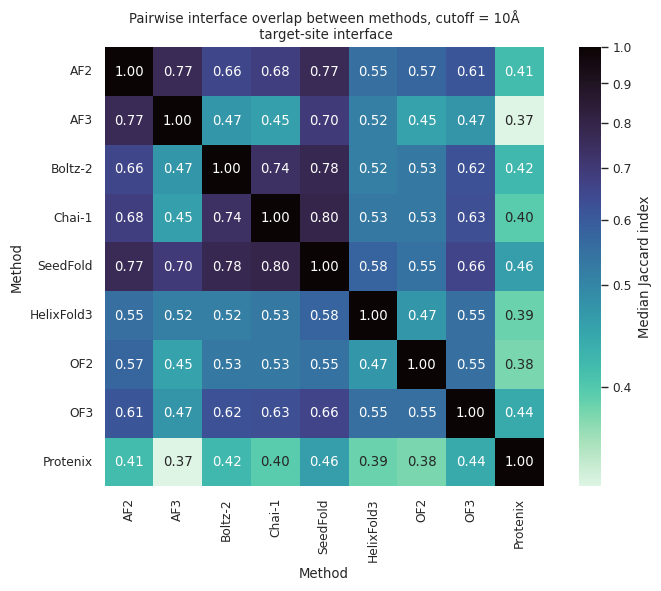

In [42]:
# Median Jaccard per method pair
jaccard_matrix = (
    jaccard_df
    .groupby(["method_1", "method_2"])["jaccard"]
    .median()
    .unstack()
)

# Make symmetric
jaccard_matrix = jaccard_matrix.combine_first(jaccard_matrix.T)

# Use one shared method order
method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

jaccard_matrix = jaccard_matrix.reindex(
    index=method_order,
    columns=method_order
)

norm = colors.PowerNorm(gamma=0.5)


# Fill diagonal
for m in method_order:
    jaccard_matrix.loc[m, m] = 1.0

plt.figure(figsize=(8, 6))
sns.heatmap(
    jaccard_matrix,
    annot=True,
    fmt=".2f",
    cmap="mako_r",
    vmin=0.4,
    vmax=1,
    square=True,
    cbar_kws={"label": "Median Jaccard index"},
    norm=norm
)

plt.title("Pairwise interface overlap between methods, cutoff = 10Å\n target-site interface")
plt.xlabel("Method")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

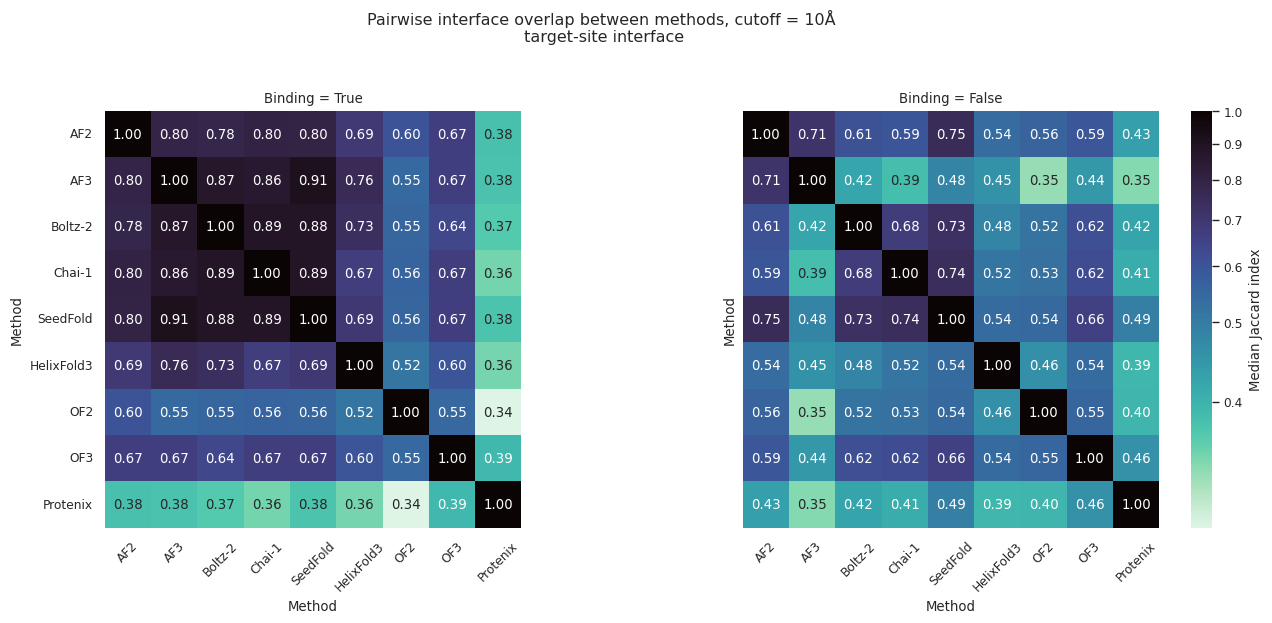

In [43]:
method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]
def make_jaccard_matrix(df):
    matrix = (
        df
        .groupby(["method_1", "method_2"])["jaccard"]
        .median()
        .unstack()
    )

    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in method_order:
        matrix.loc[m, m] = 1.0

    return matrix


binding_matrix = make_jaccard_matrix(jaccard_df[jaccard_df["Binding"] == True])
nonbinding_matrix = make_jaccard_matrix(jaccard_df[jaccard_df["Binding"] == False])

norm = colors.PowerNorm(gamma=0.5)

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="mako_r",   # ← reversed colormap
    vmin=0.4,
    vmax=1,
    square=True,
    cbar=False,
    norm=norm
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="mako_r",   # ← reversed here too
    vmin=0.4,
    vmax=1,
    square=True,
    cbar_kws={"label": "Median Jaccard index"},
    norm=norm
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Method")
    ax.set_ylabel("Method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Pairwise interface overlap between methods, cutoff = 10Å\n target-site interface", y=1.03)

plt.tight_layout()
plt.show()

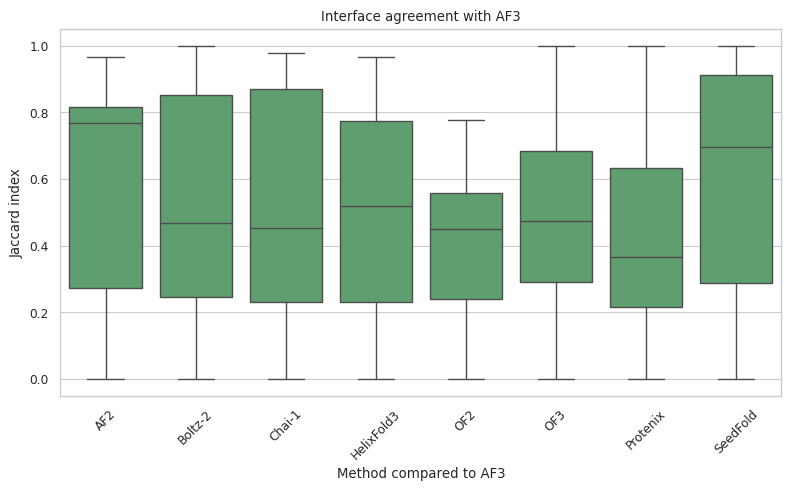

In [44]:
ref = "AF3"

ref_df = jaccard_df[
    (jaccard_df["method_1"] == ref) |
    (jaccard_df["method_2"] == ref)
].copy()

ref_df["other_method"] = ref_df.apply(
    lambda row: row["method_2"] if row["method_1"] == ref else row["method_1"],
    axis=1
)

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=ref_df,
    x="other_method",
    y="jaccard",
    color="#55A868",
)

plt.ylabel("Jaccard index")
plt.xlabel("Method compared to AF3")
plt.title("Interface agreement with AF3")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

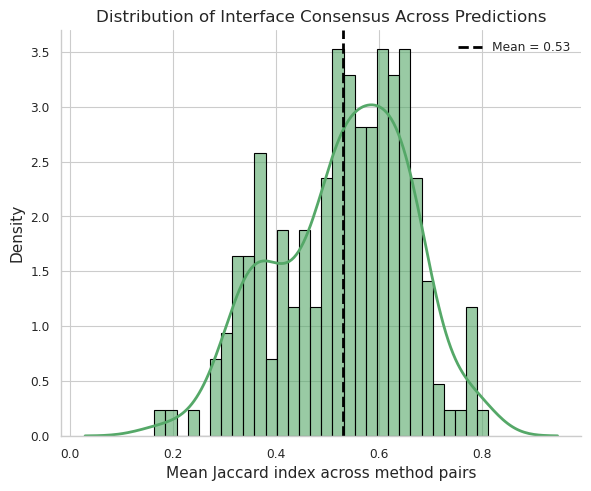

In [45]:
binder_consensus = (
    jaccard_df
    .groupby("binder_sequence")["jaccard"]
    .mean()
    .reset_index(name="mean_jaccard")
)
mean_val = binder_consensus["mean_jaccard"].mean()

sns.set(style="whitegrid", context="paper")

plt.figure(figsize=(6, 5))

# Histogram
sns.histplot(
    data=binder_consensus,
    x="mean_jaccard",
    bins=30,
    stat="density",        # important for overlaying KDE
    alpha=0.6,
    edgecolor="black",
    color="#55A868"
)

# KDE line (smooth distribution)
sns.kdeplot(
    data=binder_consensus,
    x="mean_jaccard",
    linewidth=2,
    color="#55A868"
)

# Mean line
plt.axvline(
    mean_val,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_val:.2f}",
    color="black"
)

# Labels
plt.xlabel("Mean Jaccard index across method pairs", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title("Distribution of Interface Consensus Across Predictions", fontsize=12)

# Legend
plt.legend(frameon=False)

# Clean look
sns.despine()

plt.tight_layout()
plt.show()

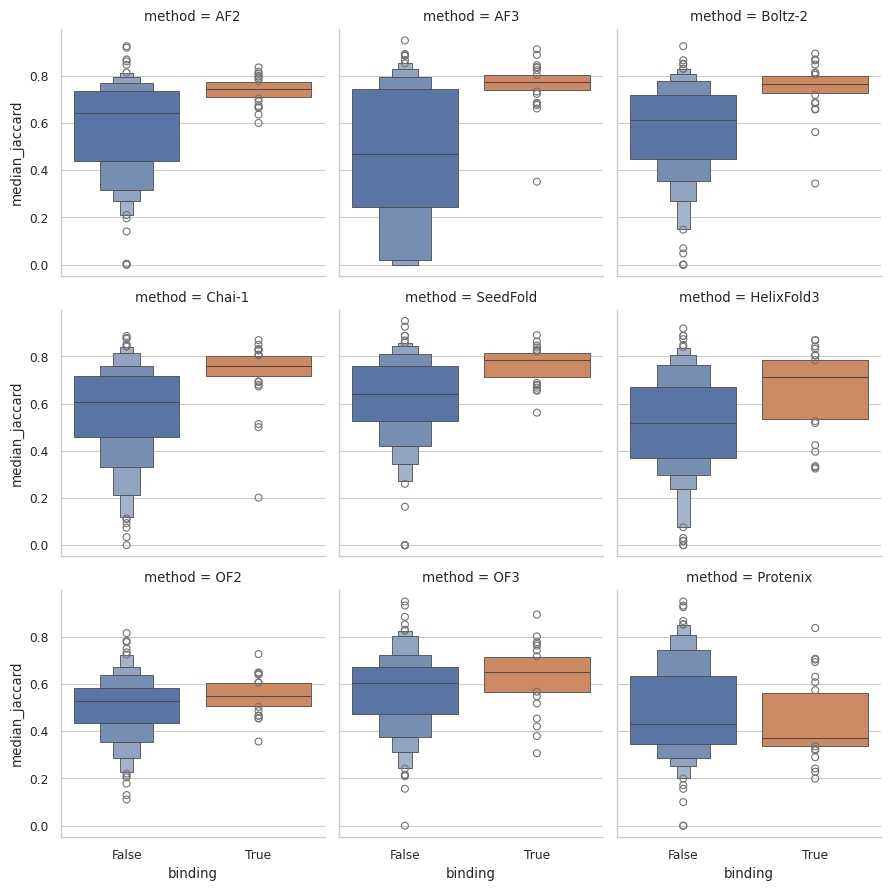

In [46]:
binder_binding = df_csv[["sequence", "binding"]].copy().drop_duplicates().rename(columns={"sequence": "binder_sequence"})

jaccard_long = pd.concat([
    jaccard_df.rename(columns={"method_1": "method", "method_2": "other"}),
    jaccard_df.rename(columns={"method_2": "method", "method_1": "other"})
])

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

model_jaccard = (
    jaccard_long
    .groupby(["binder_sequence", "method"])["jaccard"]
    .median()
    .reset_index()
    .rename(columns={"jaccard": "median_jaccard"}))

# Add binding label
model_jaccard = model_jaccard.merge(
    binder_binding,
    on="binder_sequence"
)
palette = {
    False: "#4C72B0",   # blue
    True: "#DD8452"   # orange
}

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

sns.catplot(
    data=model_jaccard,
    x="binding",
    y="median_jaccard",
    col="method",
    kind="boxen",
    col_wrap=3,
    height=3,
    sharey=True,
    hue="binding",        # ← important
    col_order=method_order,
    palette=palette,      # ← your colors
    legend=False,          # ← avoid duplicate legend per facet
)

plt.show()

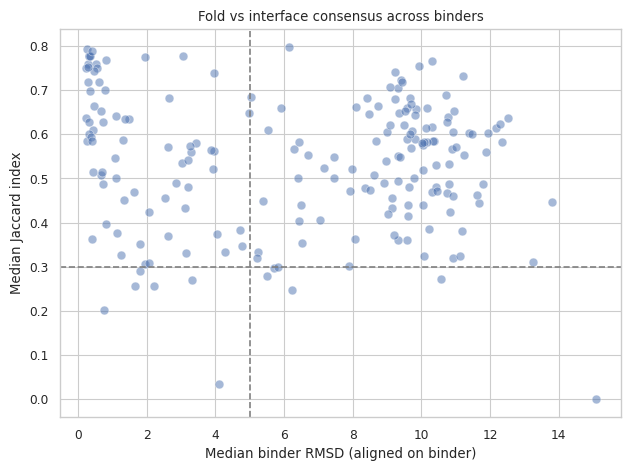

In [ ]:
# Jaccard summary per binder
binder_jaccard_summary = (
    jaccard_df
    .groupby("binder_sequence", as_index=False)["jaccard"]
    .median()
    .rename(columns={"jaccard": "median_jaccard"})
)

# RMSD summary per binder (aligned on binder)
binder_rmsd_summary = (
    plot_rmsd
    .groupby("binder_sequence", as_index=False)["binder_ca_rmsd_align_binder"]
    .median()
    .rename(columns={"binder_ca_rmsd_align_binder": "median_binder_rmsd"})
)

# Merge
consensus_df = binder_jaccard_summary.merge(
    binder_rmsd_summary,
    on="binder_sequence",
    how="inner"
)

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

sns.scatterplot(
    data=consensus_df,
    x="median_binder_rmsd",
    y="median_jaccard",
    alpha=0.5,
    s=40
)
plt.axvline(x=5, linestyle="--", color="grey")   # example RMSD cutoff
plt.axhline(y=0.3, linestyle="--", color="grey") # example Jaccard cutoff
plt.xlabel("Median binder RMSD (aligned on binder)")
plt.ylabel("Median Jaccard index")
plt.title("Fold vs interface consensus across binders")
plt.tight_layout()

plt.show()

In [54]:
plot_rmsd.head()

,binder_sequence,method_1,method_2,structure_path_1,structure_path_2,file_type_1,file_type_2,binder_chain_1,binder_chain_2,target_chain_1,...,score_name_1,score_name_2,binder_ca_rmsd_align_binder,n_ca_aligned,binder_len_1,binder_len_2,status,error,design_class,binding
36,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,AF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.cif,B,A,A,...,iptm+ptm,ranking_score,0.405979,90,90,90,ok,None,Miniprotein,False
37,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Boltz-2,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.cif,B,A,A,...,iptm+ptm,NaN,0.717255,90,90,90,ok,None,Miniprotein,False
38,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Chai-1,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.cif,B,A,A,...,iptm+ptm,aggregate_score,0.518000,90,90,90,ok,None,Miniprotein,False
39,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,HelixFold3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.cif,B,A-1,A,...,iptm+ptm,folder_rank,0.490231,90,90,90,ok,None,Miniprotein,False
40,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,OF2,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.pdb,B,A,A,...,iptm+ptm,NaN,0.253574,90,90,90,ok,None,Miniprotein,False


In [80]:
methods_to_keep = ["HelixFold3", "OF2", "OF3", "Protenix"]

rmsd_binder = plot_rmsd.copy()

# Drop old/incorrect column if present
rmsd_binder = rmsd_binder.drop(
    columns=["binder_ca_rmsd_align_target_shell"],
    errors="ignore"
)

rmsd_binder = rmsd_binder.rename(
    columns={"binder_ca_rmsd_align_binder": "rmsd_binder_aligned"}
)

rmsd_binder =rmsd_binder[rmsd_binder["method_1"].isin(methods_to_keep) & rmsd_binder["method_2"].isin(methods_to_keep)].copy()

rmsd_pocket = plot_pocket.copy()

rmsd_pocket = rmsd_pocket.rename(
    columns={
        "reference_method": "method_1",
        "query_method": "method_2",
        "binder_ca_rmsd_pocket_align": "rmsd_pocket_aligned"
    }
)

rmsd_pocket = rmsd_pocket[rmsd_pocket["method_1"].isin(methods_to_keep) & rmsd_pocket["method_2"].isin(methods_to_keep)].copy()

jaccard = jaccard_df.copy()

jaccard = jaccard.rename(
    columns={
        "Binding": "binding",
        "jaccard": "jaccard"
    }
)

jaccard = jaccard[jaccard["method_1"].isin(methods_to_keep) & jaccard["method_2"].isin(methods_to_keep)].copy()

In [81]:
binder_rmsd_summary = (
    rmsd_binder
    .groupby("binder_sequence")
    .agg(
        median_binder_aligned_rmsd=("rmsd_binder_aligned", "median"),
        mean_binder_aligned_rmsd=("rmsd_binder_aligned", "mean")
    )
    .reset_index()
)

pocket_rmsd_summary = (
    rmsd_pocket
    .groupby("binder_sequence")
    .agg(
        median_pocket_aligned_rmsd=("rmsd_pocket_aligned", "median"),
        mean_pocket_aligned_rmsd=("rmsd_pocket_aligned", "mean")
    )
    .reset_index()
)

jaccard_summary = (
    jaccard
    .groupby("binder_sequence")
    .agg(
        median_jaccard=("jaccard", "median"),
        mean_jaccard=("jaccard", "mean"),
        binding=("binding", "first")
    )
    .reset_index()
)

In [82]:
stats_df = (
    jaccard_summary
    .merge(binder_rmsd_summary, on="binder_sequence", how="left")
    .merge(pocket_rmsd_summary, on="binder_sequence", how="left")
)

stats_df["binding"] = stats_df["binding"].astype(bool)

stats_df.head()

,binder_sequence,median_jaccard,mean_jaccard,binding,median_binder_aligned_rmsd,mean_binder_aligned_rmsd,median_pocket_aligned_rmsd,mean_pocket_aligned_rmsd
0,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,0.745769,0.735533,False,0.523258,0.530507,0.947670,0.910399
1,AECPEEYKNYCKHGTCLYDVKKNKPVCLCDKGYLGPRCEKKDLSLLL,0.411076,0.456625,False,6.033155,5.464039,11.462469,10.548571
2,AESHFSECPASLQNFCQNGTCRFHVGLNQPACICNRGYIGSRCELR...,0.624676,0.628584,False,9.952502,9.414019,17.226415,16.130028
3,ANSYSPCPLEYKGYCKNGGVCVYIEATNTYACICVPGYYGPRCEYKDPK,0.394460,0.410296,False,6.507780,6.595625,17.308849,16.553757
4,APLTEYEKKIEELWDVVHNVPDMEVRRKAIDLVFDLQVTHKITEEQ...,0.692029,0.713226,True,1.942875,1.900624,3.147702,2.813327


In [83]:
def mannwhitney_with_effect_size(df, metric, group_col="binding"):
    binders = df[df[group_col] == True][metric].dropna()
    non_binders = df[df[group_col] == False][metric].dropna()

    u_stat, p_value = mannwhitneyu(
        binders,
        non_binders,
        alternative="two-sided"
    )

    n1 = len(binders)
    n2 = len(non_binders)

    # Rank-biserial correlation
    rank_biserial = (2 * u_stat) / (n1 * n2) - 1

    result = {
        "metric": metric,
        "n_binders": n1,
        "n_non_binders": n2,
        "binder_median": binders.median(),
        "non_binder_median": non_binders.median(),
        "U": u_stat,
        "p_value": p_value,
        "rank_biserial": rank_biserial
    }

    return result

metrics = [
    "median_jaccard",
    "median_binder_aligned_rmsd",
    "median_pocket_aligned_rmsd"
]

results = pd.DataFrame([
    mannwhitney_with_effect_size(stats_df, metric)
    for metric in metrics
])

results["p_adj_fdr"] = multipletests(
    results["p_value"],
    method="fdr_bh"
)[1]

results

,metric,n_binders,n_non_binders,binder_median,non_binder_median,U,p_value,rank_biserial,p_adj_fdr
0,median_jaccard,27,170,0.453846,0.454173,2358.0,0.820340,0.027451,0.820340
1,median_binder_aligned_rmsd,27,170,9.293851,7.152889,2974.0,0.013683,0.295861,0.041049
2,median_pocket_aligned_rmsd,27,170,14.887131,13.959603,2433.0,0.617331,0.060131,0.820340


bool
[False  True]


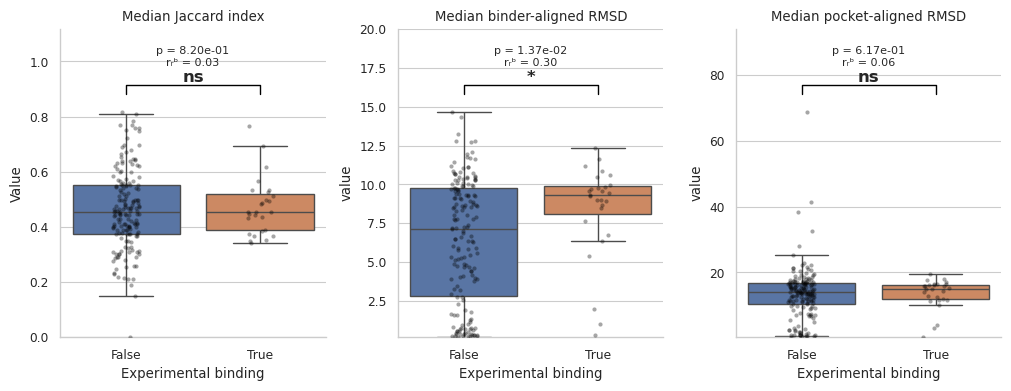

In [84]:
sns.set_theme(style="whitegrid", context="paper")

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
    

plot_df = stats_df.melt(
    id_vars=["binder_sequence", "binding"],
    value_vars=[
        "median_jaccard",
        "median_binder_aligned_rmsd",
        "median_pocket_aligned_rmsd"
    ],
    var_name="metric",
    value_name="value"
)

metric_labels = {
    "median_jaccard": "Median Jaccard index",
    "median_binder_aligned_rmsd": "Median binder-aligned RMSD",
    "median_pocket_aligned_rmsd": "Median pocket-aligned RMSD"
}

plot_df["metric"] = plot_df["metric"].map(metric_labels)

print(plot_df["binding"].dtype)
print(plot_df["binding"].unique())

palette = {
    False: "#4C72B0",
    True: "#DD8452"
}

g = sns.catplot(
    data=plot_df,
    x="binding",
    y="value",
    hue="binding",
    col="metric",
    kind="box",
    sharey=False,
    palette=palette,
    hue_order=[False, True],
    order=[False, True],
    height=4,
    aspect=0.85,
    showfliers=False,
    legend=False
)

g.set_axis_labels("Experimental binding", "Value")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    sns.stripplot(
        data=plot_df[plot_df["metric"] == ax.get_title()],
        x="binding",
        y="value",
        order=[False, True],
        color="black",
        alpha=0.35,
        size=3,
        jitter=True,
        ax=ax
    )

stats_lookup = {
    metric_labels[row["metric"]]: row
    for _, row in results.iterrows()
}

for ax in g.axes.flat:
    metric_name = ax.get_title()
    row = stats_lookup[metric_name]

    p = row["p_value"]   # or whatever your raw p-value column is called
    r_rb = row["rank_biserial"]
    stars = p_to_stars(p)

    sub = plot_df[plot_df["metric"] == metric_name]
    y_max = sub["value"].max()
    y_min = sub["value"].min()
    y_range = y_max - y_min

    # annotation height
    y = y_max + 0.08 * y_range
    h = 0.04 * y_range

    # bracket between False and True
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color="black", linewidth=1)

    # stars
    ax.text(
        0.5,
        y + h,
        stars,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    # statistical values
    ax.text(
        0.5,
        y + h + 0.08 * y_range,
        f"p = {p:.2e}\nr\u1d63\u1d47 = {r_rb:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

    # give space above plot
    ax.set_ylim(y_min, y + h + 0.25 * y_range)

sns.despine()
plt.tight_layout()
plt.show()

In [85]:
from sklearn.preprocessing import StandardScaler

model_df = stats_df.copy()

features = [
    "median_jaccard",
    "median_binder_aligned_rmsd",
    "median_pocket_aligned_rmsd"
]

model_df = model_df.dropna(subset=features + ["binding"])

scaler = StandardScaler()

z = pd.DataFrame(
    scaler.fit_transform(model_df[features]),
    columns=[f"{col}_z" for col in features],
    index=model_df.index
)

model_df = pd.concat([model_df, z], axis=1)

model_df["consensus_score"] = (
    model_df["median_jaccard_z"]
    - model_df["median_binder_aligned_rmsd_z"]
    - model_df["median_pocket_aligned_rmsd_z"]
)

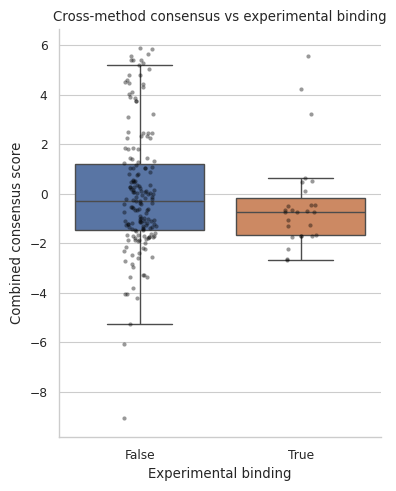

In [86]:
sns.set_theme(style="whitegrid", context="paper")

palette = {
    False: "#4C72B0",
    True: "#DD8452"
}

plt.figure(figsize=(4, 5))

ax = sns.boxplot(
    data=model_df,
    x="binding",
    y="consensus_score",
    hue="binding",
    palette=palette,
    order=[False, True],
    hue_order=[False, True],
    showfliers=False,
    legend=False
)

sns.stripplot(
    data=model_df,
    x="binding",
    y="consensus_score",
    order=[False, True],
    color="black",
    alpha=0.4,
    size=3,
    jitter=True,
    ax=ax
)

ax.set_xlabel("Experimental binding")
ax.set_ylabel("Combined consensus score")
ax.set_title("Cross-method consensus vs experimental binding")

sns.despine()
plt.tight_layout()
plt.show()

In [87]:
consensus_result = mannwhitney_with_effect_size(
    model_df,
    "consensus_score"
)

consensus_result

{'metric': 'consensus_score',
 'n_binders': 27,
 'n_non_binders': 170,
 'binder_median': np.float64(-0.7237853921221942),
 'non_binder_median': np.float64(-0.2854966266675935),
 'U': np.float64(1969.0),
 'p_value': np.float64(0.23689774627728477),
 'rank_biserial': np.float64(-0.14204793028322438)}

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, make_scorer, precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler


In [89]:
X = model_df[
    [
        "median_jaccard",
        "median_binder_aligned_rmsd",
        "median_pocket_aligned_rmsd"
    ]
]

y = model_df["binding"].astype(int)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

cv_results = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

summary = pd.DataFrame({
    metric: [
        cv_results[f"test_{metric}"].mean(),
        cv_results[f"test_{metric}"].std()
    ]
    for metric in scoring
}, index=["mean", "std"]).T

summary

,mean,std
roc_auc,0.627451,0.170094
average_precision,0.277231,0.171804
balanced_accuracy,0.649412,0.099280
precision,0.213416,0.054264
recall,0.740000,0.155492
f1,0.330343,0.078180


In [90]:
feature_sets = {
    "Jaccard only": ["median_jaccard"],
    "Binder RMSD only": ["median_binder_aligned_rmsd"],
    "Pocket RMSD only": ["median_pocket_aligned_rmsd"],
    "Consensus score": [
        "median_jaccard",
        "median_binder_aligned_rmsd",
        "median_pocket_aligned_rmsd"
    ],
    "equally weighted consensus": ["consensus_score"]
}

model_comparison = []

for name, cols in feature_sets.items():
    X_tmp = model_df[cols]
    y_tmp = model_df["binding"].astype(int)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ])

    scores = cross_validate(
        pipe,
        X_tmp,
        y_tmp,
        cv=cv,
        scoring=scoring
    )

    model_comparison.append({
        "model": name,
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "f1_mean": scores["test_f1"].mean()
    })

model_comparison = pd.DataFrame(model_comparison)
model_comparison

,model,roc_auc_mean,roc_auc_std,f1_mean
0,Jaccard only,0.403725,0.092860,0.159395
1,Binder RMSD only,0.638235,0.136598,0.335507
2,Pocket RMSD only,0.432353,0.050396,0.178534
3,Consensus score,0.627451,0.170094,0.330343
4,equally weighted consensus,0.580980,0.118723,0.289614


/tmp/ipykernel_806871/3196749137.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


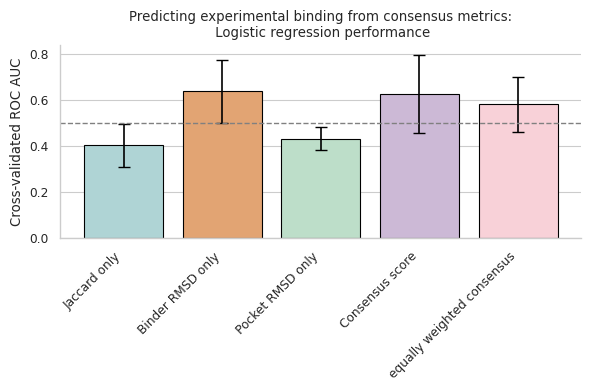

In [91]:
plt.figure(figsize=(6, 4))


for patch in ax.patches:
    patch.set_alpha(0.85)
    
pastel_palette = dict(zip(
    model_comparison["model"],
    ["#A8DADC", "#F4A261", "#B7E4C7", "#CDB4DB", "#FFCAD4"]
))

ax = sns.barplot(
    data=model_comparison,
    x="model",
    y="roc_auc_mean",
    edgecolor="black",
    palette=pastel_palette
)

ax.errorbar(
    x=range(len(model_comparison)),
    y=model_comparison["roc_auc_mean"],
    yerr=model_comparison["roc_auc_std"],
    fmt="none",
    color="black",
    capsize=4
)

ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)

ax.set_xlabel("")
ax.set_ylabel("Cross-validated ROC AUC")
ax.set_title("Predicting experimental binding from consensus metrics:\n Logistic regression performance")
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

In [34]:
final_features = [
    "median_jaccard",
    "median_binder_aligned_rmsd",
    "median_pocket_aligned_rmsd"
]

final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

final_pipe.fit(model_df[final_features], y)

coefs = pd.DataFrame({
    "feature": final_features,
    "coefficient": final_pipe.named_steps["model"].coef_[0]
})

coefs

,feature,coefficient
0,median_jaccard,0.933246
1,median_binder_aligned_rmsd,0.829705
2,median_pocket_aligned_rmsd,-0.679103


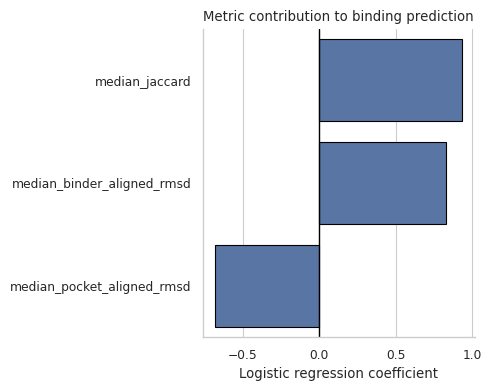

In [35]:
plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=coefs,
    x="coefficient",
    y="feature",
    edgecolor="black"
)

ax.axvline(0, color="black", linewidth=1)

ax.set_xlabel("Logistic regression coefficient")
ax.set_ylabel("")
ax.set_title("Metric contribution to binding prediction")

sns.despine()
plt.tight_layout()
plt.show()

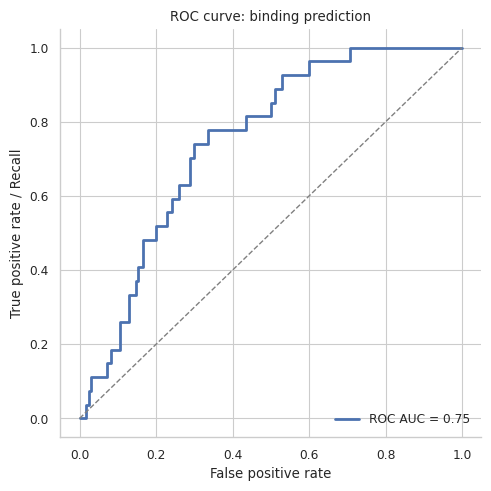

In [36]:
features = [
    "median_jaccard",
    "median_binder_aligned_rmsd",
    "median_pocket_aligned_rmsd"
]

X = model_df[features]
y = model_df["binding"].astype(int)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold predicted probabilities
y_score = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

fpr, tpr, _ = roc_curve(y, y_score)
roc_auc = auc(fpr, tpr)

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="gray")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate / Recall")
plt.title("ROC curve: binding prediction")
plt.legend(frameon=False, loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

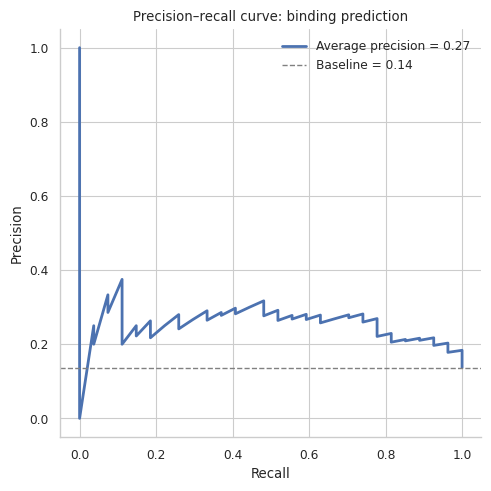

In [37]:
precision, recall, _ = precision_recall_curve(y, y_score)
avg_precision = average_precision_score(y, y_score)

baseline = y.mean()

plt.figure(figsize=(5, 5))

plt.plot(recall, precision, linewidth=2, label=f"Average precision = {avg_precision:.2f}")
plt.axhline(baseline, linestyle="--", linewidth=1, color="gray", label=f"Baseline = {baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–recall curve: binding prediction")
plt.legend(frameon=False, loc="upper right")

sns.despine()
plt.tight_layout()
plt.show()

In [38]:
# All EGFR residues contacted by any predicted binder/model
all_contacted_residues = (
    plot_target
    .groupby(["target_resseq", "target_resname"], as_index=False)
    .agg(
        n_contacts=("target_resseq", "size"),
        n_binders=("binder_sequence", "nunique"),
        methods=("method", lambda x: sorted(set(x))),
        design_classes=("design_class", lambda x: sorted(set(x))),
        mean_score=("score", "mean"),
        max_score=("score", "max"),
    )
    .sort_values("target_resseq")
)


In [39]:
max_gap = 3

all_contacted_residues["gap"] = (
    all_contacted_residues["target_resseq"].diff().fillna(0)
)

all_contacted_residues["pocket_id"] = (
    all_contacted_residues["gap"] > max_gap
).cumsum() + 1

all_pockets = (
    all_contacted_residues
    .groupby("pocket_id", as_index=False)
    .agg(
        start_resseq=("target_resseq", "min"),
        end_resseq=("target_resseq", "max"),
        residues=("target_resseq", list),
        residue_names=("target_resname", list),
        total_contacts=("n_contacts", "sum"),
        max_binders_at_residue=("n_binders", "max"),
        n_residues=("target_resseq", "size"),
        methods=("methods", lambda xs: sorted(set(m for sub in xs for m in sub))),
        design_classes=("design_classes", lambda xs: sorted(set(d for sub in xs for d in sub))),
        mean_score=("mean_score", "mean"),
        max_score=("max_score", "max"),
    )
    .sort_values("start_resseq")
)


In [40]:
residue_to_pocket = all_contacted_residues[
    ["target_resseq", "target_resname", "pocket_id"]
]

plot_target_with_pockets = plot_target.merge(
    residue_to_pocket,
    on=["target_resseq", "target_resname"],
    how="left"
)

pocket_binder_summary = (
    plot_target_with_pockets
    .groupby("pocket_id", as_index=False)
    .agg(
        start_resseq=("target_resseq", "min"),
        end_resseq=("target_resseq", "max"),
        n_binders=("binder_sequence", "nunique"),
        binders=("binder_sequence", lambda x: sorted(set(x))),
        methods=("method", lambda x: sorted(set(x))),
        total_contacts=("target_resseq", "size"),
    )
    .sort_values("n_binders", ascending=False)
)


In [41]:
all_contacted_residues = (
    plot_target
    .groupby(["target_resseq", "target_resname"], as_index=False)
    .agg(
        n_contacts=("target_resseq", "size"),
        n_binders=("binder_sequence", "nunique"),
        methods=("method", lambda x: sorted(set(x))),
        design_classes=("design_class", lambda x: sorted(set(x))),
        mean_score=("score", "mean"),
        max_score=("score", "max"),
    )
    .sort_values("target_resseq")
)

max_gap = 3

all_contacted_residues["gap"] = (
    all_contacted_residues["target_resseq"].diff().fillna(0)
)

all_contacted_residues["pocket_id"] = (
    all_contacted_residues["gap"] > max_gap
).cumsum() + 1

all_pockets = (
    all_contacted_residues
    .groupby("pocket_id", as_index=False)
    .agg(
        start_resseq=("target_resseq", "min"),
        end_resseq=("target_resseq", "max"),
        residues=("target_resseq", list),
        residue_names=("target_resname", list),
        total_contacts=("n_contacts", "sum"),
        n_residues=("target_resseq", "size"),
        max_binders_at_residue=("n_binders", "max"),
        methods=("methods", lambda xs: sorted(set(m for sub in xs for m in sub))),
    )
    .sort_values("start_resseq")
)

print("Unique binders represented:", plot_target["binder_sequence"].nunique())
print("Contacted EGFR residues:", len(all_contacted_residues))
print("Predicted binding pockets:", len(all_pockets))


Unique binders represented: 197
Contacted EGFR residues: 595
Predicted binding pockets: 4


In [42]:
tail_pocket_id = 4  # change this

tail_residues = all_pockets.loc[
    all_pockets["pocket_id"] == tail_pocket_id,
    "residues"
].iloc[0]

tail_rows = plot_target.query("target_resseq in @tail_residues")

print("Residues:", tail_residues)
print("Rows/contacts:", len(tail_rows))
print("Unique binders:", tail_rows["binder_sequence"].nunique())
print("Methods:", tail_rows["method"].unique())

tail_rows[
    [
        "method",
        "target_chain_id",
        "target_resname",
        "target_resseq",
        "score",
        "binder_sequence",
        "path",
    ]
].drop_duplicates().sort_values(["target_resseq", "method"])


Residues: [511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 611, 612, 613, 614, 615, 616, 617, 618, 619, 620, 621]
Rows/contacts: 1576
Unique binders: 44
Methods: <ArrowStringArray>
['Protenix', 'AF2', 'AF3', 'SeedFold', 'Boltz-2', 'Chai-1', 'OF2']
Length: 7, dtype: str


,method,target_chain_id,target_resname,target_resseq,score,binder_sequence,path
146263,AF2,A,CYS,511,0.889952,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
196087,AF3,B,CYS,511,0.340000,QMQLSQSGPGLVQPGQSSRITGAVSGFSHMNYGTHWYRQAPRKTLE...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
146418,Chai-1,B,CYS,511,0.645717,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
146568,OF2,B,CYS,511,NaN,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
146742,Protenix,B,CYS,511,0.900230,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
...,...,...,...,...,...,...,...
332194,Protenix,B,SER,621,0.405151,SSAVPCGPEHRGFCVHGTCRYHPLLNQVCCVCHDGWTGERCELPDLLAI,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
335567,Protenix,B,SER,621,0.471440,SSFSSYCLHGTPFYESSLNKWSCRCDKGYYGPRCEYKDLL,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
365059,Protenix,B,SER,621,0.581508,TRLGTPVYVYADYDTP,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
378872,Protenix,B,SER,621,0.871823,YNETVIRITDMTARENSQVRNMYEATTVKKIEIITTKTDIVLGNMH...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...


In [43]:
tail_rows_af3 = tail_rows[tail_rows["method"] == "AF3"]

tail_rows_af3[
    [
        "method",
        "target_chain_id",
        "target_resname",
        "target_resseq",
        "score",
        "binder_sequence",
        "path",
    ]
].drop_duplicates().sort_values(["target_resseq", "method"])


,method,target_chain_id,target_resname,target_resseq,score,binder_sequence,path
196087,AF3,B,CYS,511,0.34,QMQLSQSGPGLVQPGQSSRITGAVSGFSHMNYGTHWYRQAPRKTLE...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
20159,AF3,B,VAL,512,0.32,CKLVSATVTVDSSTGQAQVVAKNECLGVQTFTAATAAEALAKMQAAIAA,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
146316,AF3,B,VAL,512,0.86,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
196088,AF3,B,VAL,512,0.34,QMQLSQSGPGLVQPGQSSRITGAVSGFSHMNYGTHWYRQAPRKTLE...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
368788,AF3,B,VAL,512,0.34,TWTTVITILKKMDWRASEMMNVATAVTINEMGIVRKQNVIEAGSEI...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
...,...,...,...,...,...,...,...
51373,AF3,B,ILE,619,0.36,EQEKADVINEYREKKAFAFF,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
356354,AF3,B,ILE,619,0.28,TCPEYYKGYCLHNAECYYIEALNDVGCQCKKGFVGPRCSFKNLNDGN,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
51374,AF3,B,PRO,620,0.36,EQEKADVINEYREKKAFAFF,/home/postyr/Assessing-AI-Scoring-Accuracy-for...
356355,AF3,B,PRO,620,0.28,TCPEYYKGYCLHNAECYYIEALNDVGCQCKKGFVGPRCSFKNLNDGN,/home/postyr/Assessing-AI-Scoring-Accuracy-for...


In [44]:
print(plot_target.at[11027, "path"])

/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Predictions/Boltz-2/nitesh.mishra3.stepwise_egf_based_egfr_binder_3/nitesh.mishra3.stepwise_egf_based_egfr_binder_3_model_0.cif


In [45]:
tail_rows.groupby("method").agg(
    n_contacts=("target_resseq", "size"),
    n_binders=("binder_sequence", "nunique"),
    min_resseq=("target_resseq", "min"),
    max_resseq=("target_resseq", "max"),
    mean_score=("score", "mean"),
    max_score=("score", "max"),
).sort_values("n_binders", ascending=False)


,n_contacts,n_binders,min_resseq,max_resseq,mean_score,max_score
method,,,,,,
Protenix,163,21,511,621,0.560872,0.912323
AF3,861,20,511,621,0.349570,0.860000
SeedFold,180,5,511,621,0.868452,0.906624
AF2,189,4,511,602,0.588073,0.889952
Boltz-2,90,2,512,592,NaN,NaN
OF2,49,1,511,567,NaN,NaN
Chai-1,44,1,511,567,0.645717,0.645717


In [46]:
suspicious_pocket_id = 4
sus_residues = all_pockets.loc[
    all_pockets["pocket_id"] == suspicious_pocket_id,
    "residues"
].iloc[0]

plot_target.query("target_resseq in @sus_residues")[
    [
        "binder_sequence",
        "method",
        "path",
        "target_chain_id",
        "target_resname",
        "target_resseq",
        "score",
        "score_name",
        "contact_cutoff",
        "design_class",
    ]
].sort_values(["target_resseq", "method", "score"], ascending=[True, True, False])


,binder_sequence,method,path,target_chain_id,target_resname,target_resseq,score,score_name,contact_cutoff,design_class
146263,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,AF2,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,A,CYS,511,0.889952,iptm+ptm,10.0,Miniprotein
196087,QMQLSQSGPGLVQPGQSSRITGAVSGFSHMNYGTHWYRQAPRKTLE...,AF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,B,CYS,511,0.340000,ranking_score,10.0,Peptide
146418,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,Chai-1,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,B,CYS,511,0.645717,aggregate_score,10.0,Miniprotein
146568,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,OF2,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,B,CYS,511,NaN,NaN,10.0,Miniprotein
146742,MSKESLRLTLKQIIDSYTSLSPEKREEAEKKAEELLEEMQGLNTEE...,Protenix,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,B,CYS,511,0.900230,ranking_score,10.0,Miniprotein
...,...,...,...,...,...,...,...,...,...,...
170081,NSPNSCPPSHDGYCKHGGVCTYIPALNKYACNCVVGYIGERCQYRD...,Protenix,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,B,SER,621,0.457570,ranking_score,10.0,Peptide
72745,FFYYSMCPLSHDGYCLHDGVCMYIEALDKYACNCVVGYIGERCQYR...,Protenix,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,B,SER,621,0.416316,ranking_score,10.0,Peptide
332194,SSAVPCGPEHRGFCVHGTCRYHPLLNQVCCVCHDGWTGERCELPDLLAI,Protenix,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,B,SER,621,0.405151,ranking_score,10.0,Peptide
11589,ANSYSPCPLEYKGYCKNGGVCVYIEATNTYACICVPGYYGPRCEYKDPK,Protenix,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,B,SER,621,0.374035,ranking_score,10.0,Peptide


In [47]:
target_object = "target"
target_chain = "B"

pml_out = Path("all_predicted_egfr_binding_pockets.pml")


def pymol_resi_selection(residues):
    """
    Converts residue numbers into a PyMOL-friendly resi selection:
    resi 314+315+316
    """
    residues = sorted(set(int(r) for r in residues))
    return "+".join(map(str, residues))


# Show only stronger consensus binding residues:
# residues contacted by at least 20 unique binders and at least 3 methods
min_binders = 20
min_methods = 3

residue_summary = (
    plot_target
    .dropna(subset=["target_resseq", "binder_sequence", "method"])
    .assign(target_resseq=lambda df: df["target_resseq"].astype(int))
    .groupby("target_resseq")
    .agg(
        unique_binders=("binder_sequence", "nunique"),
        unique_methods=("method", "nunique"),
        contact_rows=("target_resseq", "size"),
    )
)

selected_residues = residue_summary[
    (residue_summary["unique_binders"] >= min_binders) &
    (residue_summary["unique_methods"] >= min_methods)
].index.tolist()

all_resi_sel = pymol_resi_selection(selected_residues)

print("Methods:", sorted(plot_target["method"].dropna().unique()))
print("Unique methods:", plot_target["method"].nunique())
print("Unique binders:", plot_target["binder_sequence"].nunique())
print("Residues shown:", len(selected_residues))
print(
    residue_summary
    .loc[selected_residues]
    .sort_values(["unique_binders", "unique_methods"], ascending=False)
    .head(30)
)


print("Methods:", sorted(plot_target["method"].dropna().unique()))
print("Unique methods:", plot_target["method"].nunique())
print("Unique binders:", plot_target["binder_sequence"].nunique())
print("Contacted target residues:", len(selected_residues))


with open(pml_out, "w") as f:
    f.write(f"""
hide everything
show cartoon, {target_object} and chain {target_chain}
color gray80, {target_object} and chain {target_chain}

set cartoon_transparency, 0.15
set transparency, 0.35
set surface_quality, 1
set ray_opaque_background, off
set antialias, 2

bg_color white

set_color binding_hotpink, [1.0, 0.05, 0.55]

select all_predicted_binding_residues, {target_object} and chain {target_chain} and resi {all_resi_sel}
show surface, all_predicted_binding_residues
color binding_hotpink, all_predicted_binding_residues

""")

    # Optional: make named selections for each pocket, but do not recolor them
    for _, row in all_pockets.iterrows():
        pocket_id = int(row["pocket_id"])
        residues = row["residues"]
        resi_sel = pymol_resi_selection(residues)

        f.write(f"""
select pocket_{pocket_id}, {target_object} and chain {target_chain} and resi {resi_sel}

""")

    f.write("""
orient all_predicted_binding_residues
zoom all_predicted_binding_residues, 12
set label_size, 18

# Optional labels for pocket centers
""")

    for _, row in all_pockets.iterrows():
        pocket_id = int(row["pocket_id"])
        residues = sorted(set(int(r) for r in row["residues"]))
        center_residue = residues[len(residues) // 2]

        f.write(
            f'label {target_object} and chain {target_chain} and resi {center_residue} and name CA, "P{pocket_id}"\n'
        )

print(f"Wrote: {pml_out}")


Methods: ['AF2', 'AF3', 'Boltz-2', 'Chai-1', 'HelixFold3', 'OF2', 'OF3', 'Protenix', 'SeedFold']
Unique methods: 9
Unique binders: 197
Residues shown: 236
               unique_binders  unique_methods  contact_rows
target_resseq                                              
12                        197               9          1433
13                        197               9          1426
14                        197               9          1427
15                        197               9          1435
16                        197               9          1435
17                        197               9          1431
18                        197               9          1429
19                        197               9          1423
20                        197               9          1433
21                        197               9          1359
22                        197               9          1377
23                        197               9          1428
44   

In [48]:
method_residue_matrix = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .unstack(fill_value=0)
)

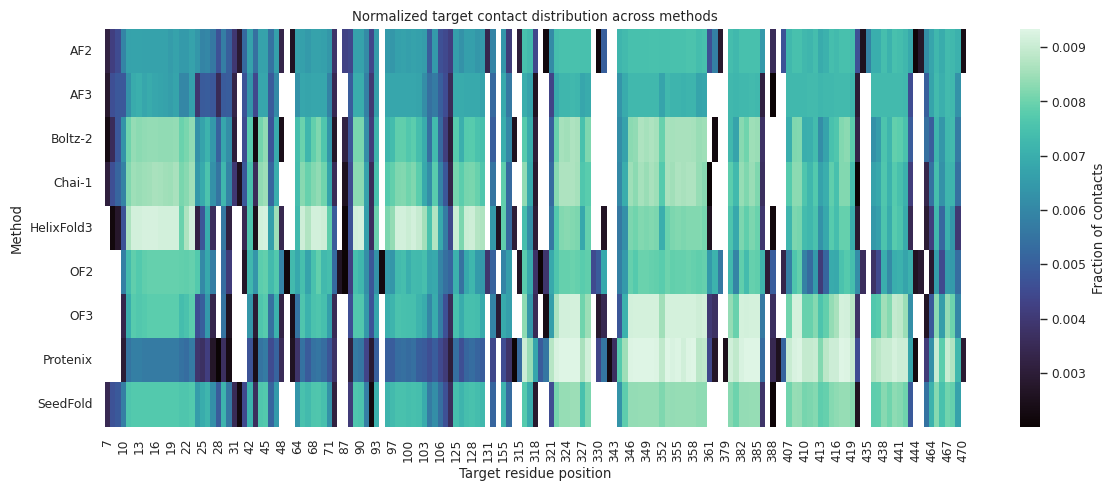

In [49]:
# Normalize within each method
contact_fraction_matrix = (
    method_residue_matrix
    .div(method_residue_matrix.sum(axis=1), axis=0)
    .fillna(0)
)

# Set your visibility threshold
threshold = 0.002

# Keep only values above threshold
plot_matrix = contact_fraction_matrix.where(contact_fraction_matrix >= threshold)

# Drop residue columns where no method has a visible hit
plot_matrix = plot_matrix.loc[:, plot_matrix.notna().any(axis=0)]

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(12, 5))
ax = sns.heatmap(
    plot_matrix,
    cmap="mako",
    mask=plot_matrix.isna(),
    cbar_kws={"label": "Fraction of contacts"}
)

ax.set_xlabel("Target residue position")
ax.set_ylabel("Method")
ax.set_title("Normalized target contact distribution across methods")

plt.tight_layout()
plt.show()

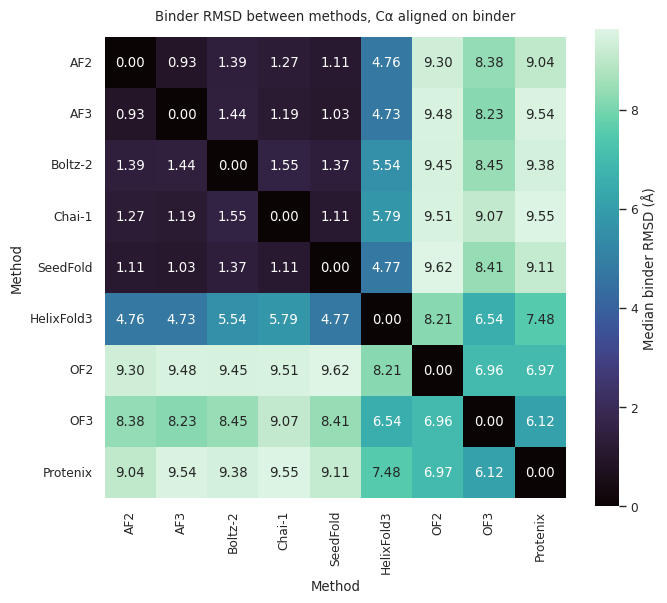

In [50]:
rmsd_col = "binder_ca_rmsd_align_binder"

rmsd_matrix = (
    plot_rmsd
    .groupby(["method_1", "method_2"])[rmsd_col]
    .median()
    .unstack()
)

# method_order = [
#     "AF2", "AF3", "Boltz-2", "Chai-1",
#     "SeedFold", "HelixFold3",
#     "OF2", "OF3", "Protenix"
# ]

# rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

# for m in method_order:
#     if pd.isna(rmsd_matrix.loc[m, m]):
#         rmsd_matrix.loc[m, m] = 0.0

rmsd_matrix = rmsd_matrix.combine_first(rmsd_matrix.T)

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]
rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

for m in rmsd_matrix.index:
    rmsd_matrix.loc[m, m] = 0.0


sns.set_theme(style="white", context="paper")

plt.figure(figsize=(7, 6))

mask = rmsd_matrix.isna()

ax = sns.heatmap(
    rmsd_matrix,
    mask=mask,
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Median binder RMSD (Å)"}
)


ax.set_title("Binder RMSD between methods, Cα aligned on binder", pad=12)
ax.set_ylabel("Method")
ax.set_xlabel("Method")

plt.tight_layout()
plt.show()

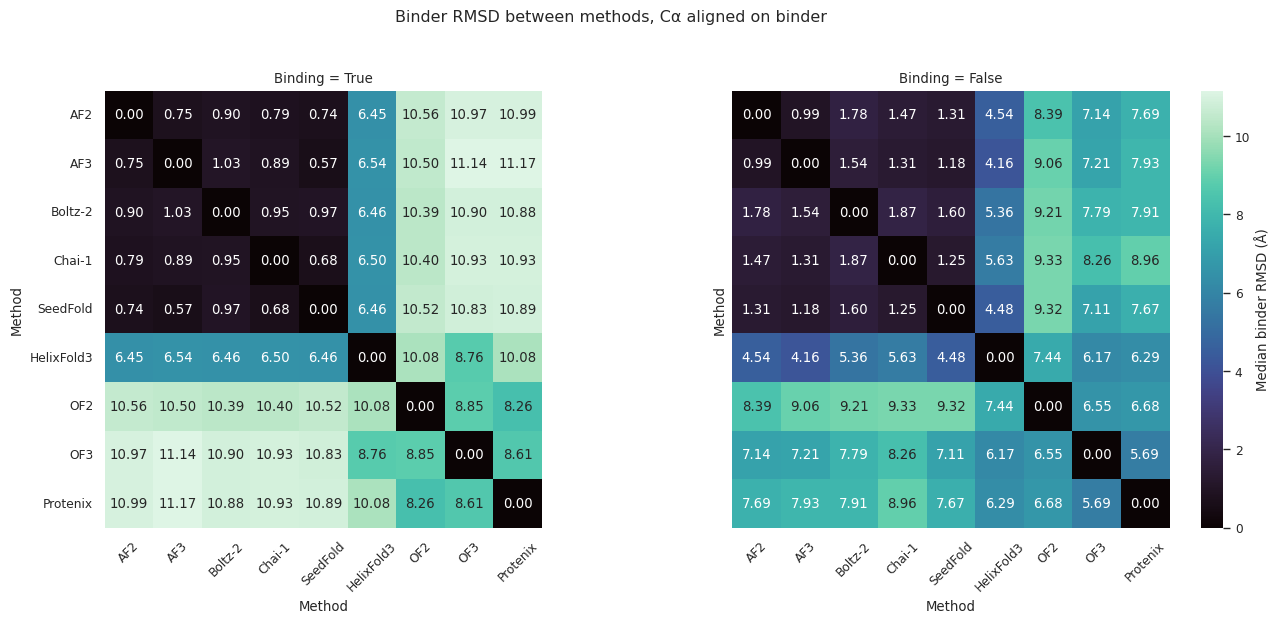

In [51]:
rmsd_col = "binder_ca_rmsd_align_binder"

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

# def make_rmsd_matrix(df):
#     matrix = (
#         df
#         .groupby(["method_1", "method_2"])[rmsd_col]
#         .median()
#         .unstack()
#     )

#     matrix = matrix.reindex(index=method_order, columns=method_order)

#     for m in method_order:
#         matrix.loc[m, m] = 0.0

#     return matrix

def make_rmsd_matrix(df):
    matrix = (
        df
        .groupby(["method_1", "method_2"])[rmsd_col]
        .median()
        .unstack()
    )

    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in matrix.index:
        matrix.loc[m, m] = 0.0

    return matrix

binding_matrix = make_rmsd_matrix(
    plot_rmsd[plot_rmsd["binding"] == True]
)

nonbinding_matrix = make_rmsd_matrix(
    plot_rmsd[plot_rmsd["binding"] == False]
)

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

vmin = min(binding_matrix.min().min(), nonbinding_matrix.min().min())
vmax = max(binding_matrix.max().max(), nonbinding_matrix.max().max())

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar=False
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": "Median binder RMSD (Å)"}
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Method")
    ax.set_ylabel("Method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Binder RMSD between methods, Cα aligned on binder",
    y=1.03
)

plt.tight_layout()
plt.show()

In [52]:
ref = "AF3"
rmsd_col = "binder_ca_rmsd_align_binder"  # adjust if needed

af3_as_1 = plot_rmsd[plot_rmsd["method_1"] == ref].copy()
af3_as_1["other_method"] = af3_as_1["method_2"]

af3_as_2 = plot_rmsd[plot_rmsd["method_2"] == ref].copy()
af3_as_2["other_method"] = af3_as_2["method_1"]

af3_all = pd.concat([af3_as_1, af3_as_2], ignore_index=True)

print(sorted(af3_all["other_method"].unique()))

['AF2', 'Boltz-2', 'Chai-1', 'HelixFold3', 'OF2', 'OF3', 'Protenix', 'SeedFold']


In [53]:
(af3_as_1["binder_ca_rmsd_align_binder"] < 0).any()


np.False_

In [54]:
chosen_seq = "SRLEEIVRETLRENGFSEEEIEHITWHFLLLWGSLERTYPHWSEEERVRRAAEYTQMMHPEITPEMVEKLVSRV"
rmsd_af3_all = af3_as_1[af3_as_1["binder_sequence"] == chosen_seq]

rmsd_af3_all[["method_1", "method_2", "binder_ca_rmsd_align_binder"]]

,method_1,method_2,binder_ca_rmsd_align_binder
12467,AF3,Boltz-2,0.448927
12468,AF3,Chai-1,0.476942
12469,AF3,HelixFold3,0.256227
12470,AF3,OF2,0.354933
12471,AF3,OF3,0.298080
12472,AF3,Protenix,0.241370
12473,AF3,SeedFold,0.448075


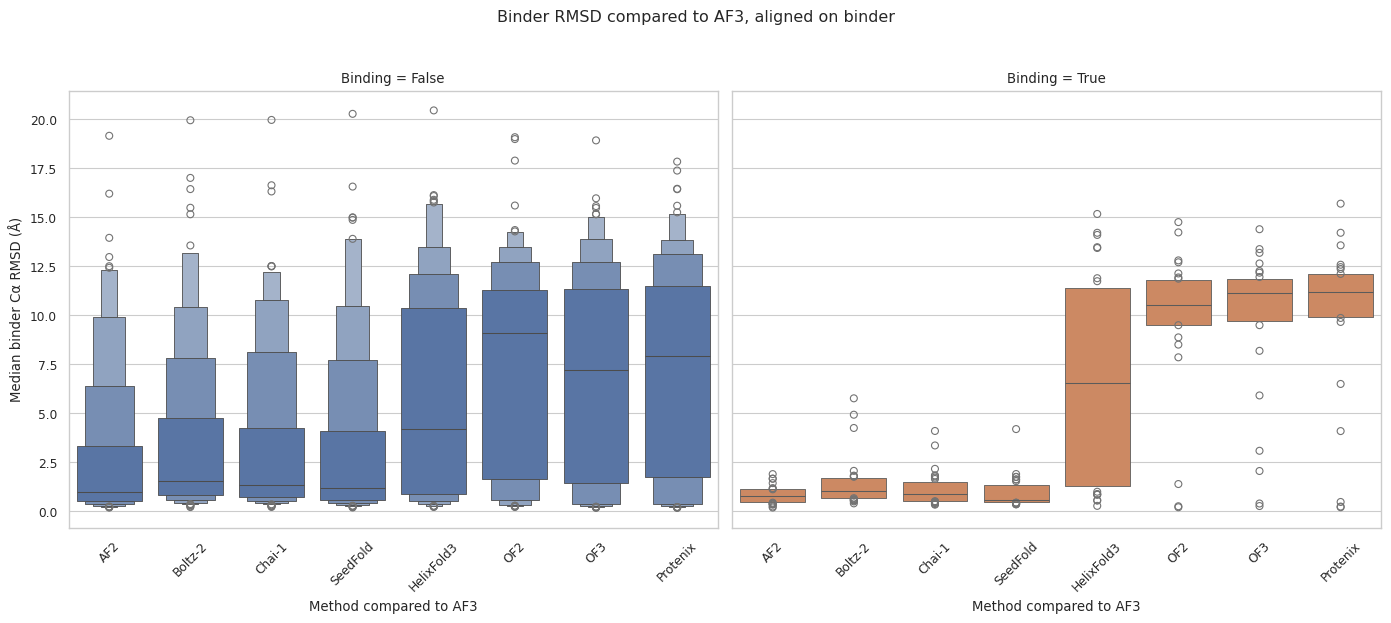

In [55]:
sns.set_theme(style="whitegrid", context="paper")

af3_nonbinding = af3_all[af3_all["binding"] == False]
af3_binding = af3_all[af3_all["binding"] == True]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

method_order = [
    "AF2", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

sns.boxenplot(
    ax=axes[0],
    data=af3_nonbinding,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    color="#4C72B0",
    width_method="linear",
    order=method_order
)


sns.boxenplot(
    ax=axes[1],
    data=af3_binding,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    color="#DD8452",
    width_method="linear",
    order=method_order
)

axes[0].set_title("Binding = False")
axes[1].set_title("Binding = True")

for ax in axes:
    ax.set_ylabel("Median binder Cα RMSD (Å)")
    ax.set_xlabel("Method compared to AF3")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Binder RMSD compared to AF3, aligned on binder", y=1.03)

plt.tight_layout()
plt.show()


In [56]:
import pandas as pd

rmsd_col = "binder_ca_rmsd_align_binder"

# Stack both columns into one unified "method" column
part1 = plot_rmsd[["method_1", rmsd_col]].rename(columns={"method_1": "method"})
part2 = plot_rmsd[["method_2", rmsd_col]].rename(columns={"method_2": "method"})

long_df = pd.concat([part1, part2], ignore_index=True)

summary = (
    long_df
    .groupby("method")[rmsd_col]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

print(summary)

                mean    median       std  count
method                                         
AF2         4.813116  2.577736  4.688113   1576
SeedFold    4.853085  2.904166  4.648256   1576
AF3         4.906886  2.239072  4.891615   1576
Boltz-2     5.077647  3.209745  4.595226   1576
Chai-1      5.122934  3.246712  4.673740   1576
HelixFold3  6.218858  6.136743  4.727907   1576
OF3         6.946753  7.575442  4.602364   1576
Protenix    7.059587  7.886349  4.673959   1576
OF2         7.377576  8.573551  4.565629   1576


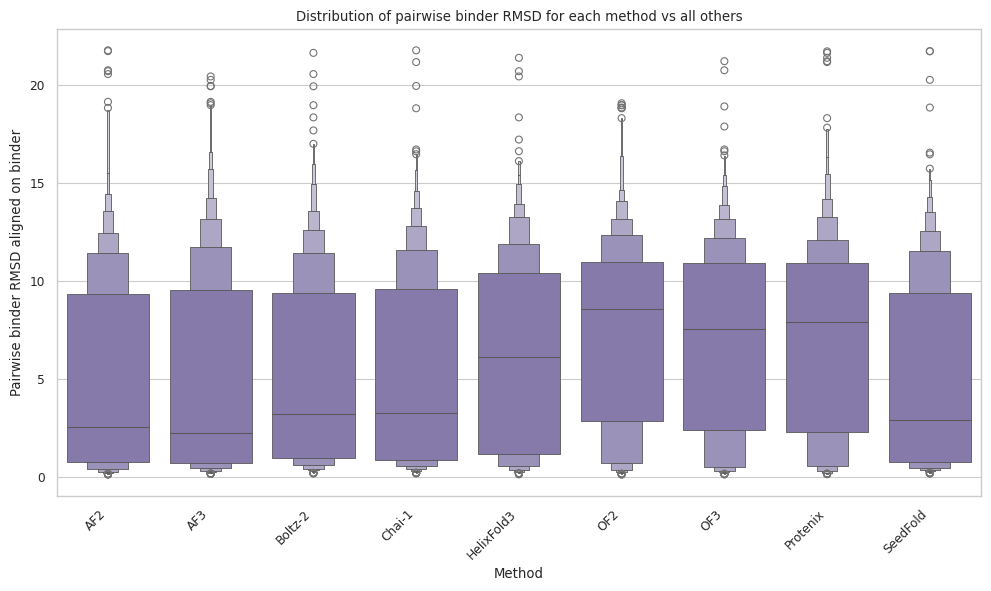

In [57]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.boxenplot(
    data=long_df,
    x="method",
    y=rmsd_col,
    color = "#8172B2"
)

plt.xlabel("Method")
plt.ylabel("Pairwise binder RMSD aligned on binder")
plt.title("Distribution of pairwise binder RMSD for each method vs all others")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

which methods tend to produce poses most similar to the overall consensus across binders?

The lower the Pairwise RMSD, the more in agreement the model is in general with the other models.